In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import random
import string
import math

In [9]:


# 1. Valor teórico
casos_favorables = math.comb(5, 2) * math.comb(21, 2)
casos_totales = math.comb(26, 4)
prob_teorica = casos_favorables / casos_totales
print(f"Probabilidad teórica P(A): {prob_teorica:.4f}")

# 2. Función para generar contraseña
def generar_contrasena():
    letras = random.sample(string.ascii_lowercase, 4)
    digitos = random.choices(string.digits, k=3)
    return "".join(letras + digitos)

# 3. Simulación
N = 10000
exitos = 0
vocales = set("aeiou")

for _ in range(N):
    pwd = generar_contrasena()
    num_vocales = sum(1 for char in pwd[:4] if char in vocales)
    if num_vocales == 2:
        exitos += 1

prob_simulada = exitos / N
print(f"Probabilidad simulada P(A): {prob_simulada:.4f}")

Probabilidad teórica P(A): 0.1405
Probabilidad simulada P(A): 0.1443


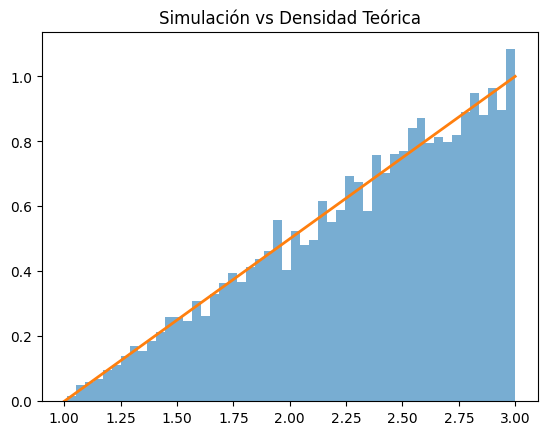

In [10]:
import numpy as np
import matplotlib.pyplot as plt

u = np.random.uniform(0, 1, 10000)
x_simulados = 1 + 2 * np.sqrt(u)

x_teorico = np.linspace(1, 3, 100)
f_teorica = 0.5 * (x_teorico - 1)

plt.hist(x_simulados, bins=50, density=True, alpha=0.6)
plt.plot(x_teorico, f_teorica, lw=2)
plt.title('Simulación vs Densidad Teórica')
plt.show()

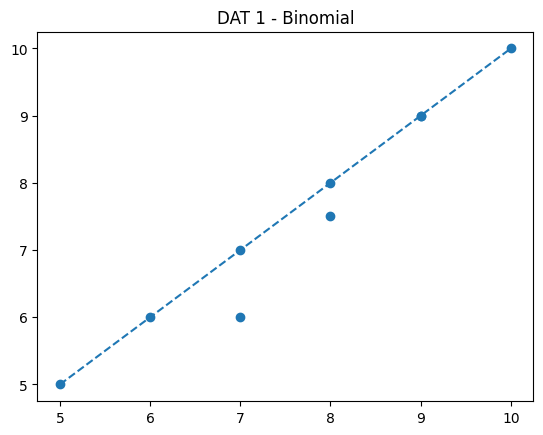

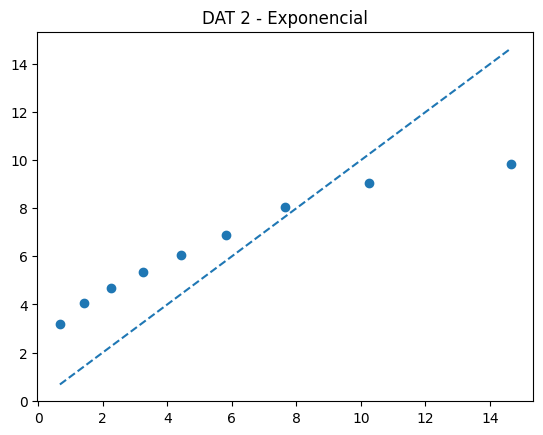

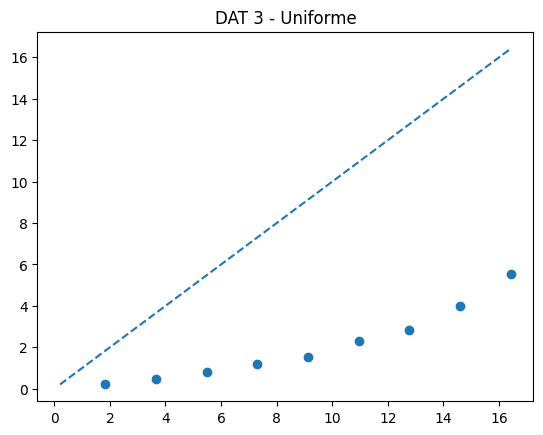

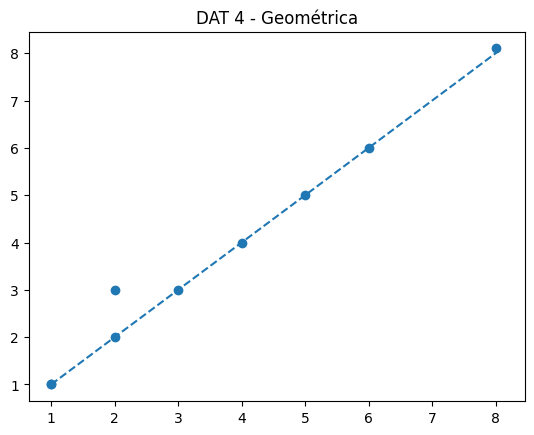

In [11]:
import scipy.stats as stats

def plot_qq(datos, distribucion, parametros, titulo):
    deciles = np.arange(0.1, 1.0, 0.1)
    q_empiricos = np.quantile(datos, deciles)

    if distribucion == 'binomial':
        n, p = parametros
        q_teoricos = stats.binom.ppf(deciles, n, p)
    elif distribucion == 'exponencial':
        scale = 1 / parametros[0]
        q_teoricos = stats.expon.ppf(deciles, scale=scale)
    elif distribucion == 'uniforme':
        a, b = parametros
        q_teoricos = stats.uniform.ppf(deciles, loc=a, scale=b-a)
    elif distribucion == 'geometrica':
        p = parametros[0]
        q_teoricos = stats.geom.ppf(deciles, p)

    plt.scatter(q_teoricos, q_empiricos)
    min_val = min(min(q_teoricos), min(q_empiricos))
    max_val = max(max(q_teoricos), max(q_empiricos))
    plt.plot([min_val, max_val], [min_val, max_val], '--')
    plt.title(titulo)
    plt.show()

dat1 = np.loadtxt('dat1.txt')
media1, var1 = np.mean(dat1), np.var(dat1, ddof=1)
p_est = 1 - (var1 / media1)
n_est = round(media1 / p_est)
plot_qq(dat1, 'binomial', (n_est, p_est), 'DAT 1 - Binomial')

dat2 = np.loadtxt('dat2.txt')
lambda_est = 1 / np.mean(dat2)
plot_qq(dat2, 'exponencial', (lambda_est,), 'DAT 2 - Exponencial')

dat3 = np.loadtxt('dat3.txt')
a_est, b_est = np.min(dat3), np.max(dat3)
plot_qq(dat3, 'uniforme', (a_est, b_est), 'DAT 3 - Uniforme')

dat4 = np.loadtxt('dat4.txt')
p_geom_est = 1 / np.mean(dat4)
plot_qq(dat4, 'geometrica', (p_geom_est,), 'DAT 4 - Geométrica')